# 02 — Filtros convencionais: projeto, validação e formalização

Notch IIR 60 Hz · Passa-alta IIR Butterworth 0,5 Hz · Passa-baixa FIR Hamming 40 Hz.
Gera as figuras de formalização (polos/zeros, |H(e^jω)|, atraso de grupo, FFT) usadas no relatório.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # raiz do repo no path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from src.data_io import ensure_datasets, load_ecg, FS
from src.noise.contaminate import contaminate
from src.filters.notch import design_notch, apply_notch
from src.filters.highpass import design_highpass, apply_highpass
from src.filters.lowpass_fir import design_lowpass_fir, apply_lowpass_fir, group_delay_samples
from src.metrics.metrics import summary
from src.viz import plots
ensure_datasets(); clean, fs = load_ecg('100')

## 1. Notch IIR 60 Hz (`iirnotch`, Q = f0/BW = 60/2 = 30)

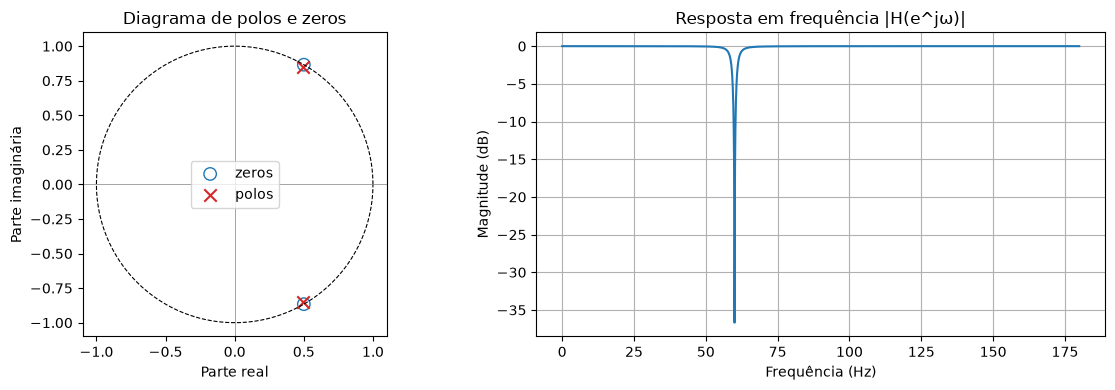

In [3]:
b, a = design_notch(f0=60, fs=fs, bw=2)
fig, axs = plt.subplots(1, 2, figsize=(12,4))
plots.plot_pole_zero(b, a, ax=axs[0]); plots.plot_freq_response(b, a, fs=fs, ax=axs[1])
fig.tight_layout()

{'snr_in_db': 5.999999999999998, 'snr_out_db': 34.538691150599384, 'snr_improvement_db': 28.538691150599384, 'rmse': 0.006791121811048489, 'prd': 1.8752770663831255, 'corr': 0.999382065909948}


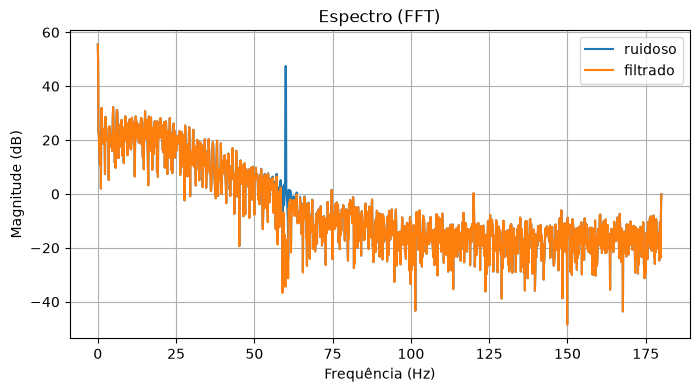

In [4]:
noisy = contaminate(clean, '60hz', 6); filt = apply_notch(noisy)
fig, ax = plt.subplots(figsize=(8,4))
plots.plot_spectrum(noisy[:3600], fs=fs, ax=ax, label='ruidoso')
plots.plot_spectrum(filt[:3600], fs=fs, ax=ax, label='filtrado')
print(summary(clean, noisy, filt))

## 2. Passa-alta IIR Butterworth 0,5 Hz (`butter` + `filtfilt`)

**Nota de protocolo:** o ECG do mitdb já contém conteúdo <0,5 Hz; para avaliar a remoção da deriva de forma justa, comparamos contra `ref = apply_highpass(clean)`.

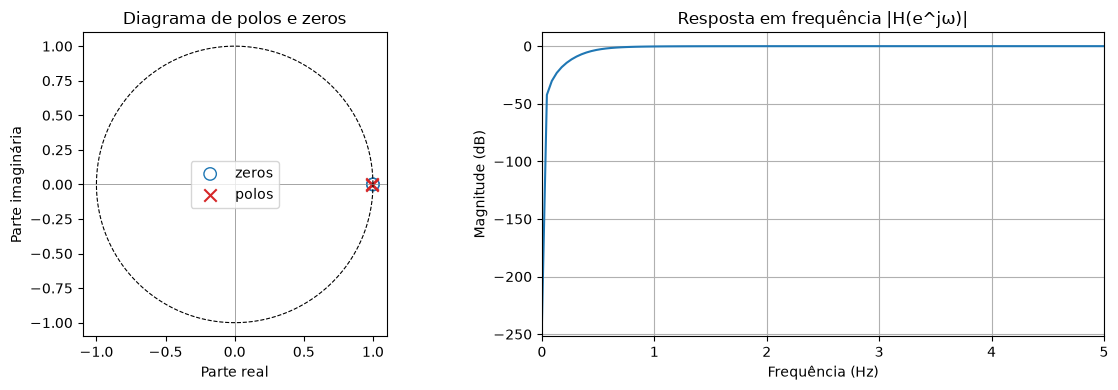

In [5]:
b, a = design_highpass(fc=0.5, fs=fs, order=2)
fig, axs = plt.subplots(1, 2, figsize=(12,4))
plots.plot_pole_zero(b, a, ax=axs[0]); plots.plot_freq_response(b, a, fs=fs, ax=axs[1])
axs[1].set_xlim(0, 5); fig.tight_layout()

{'snr_in_db': 0.2532167029877529, 'snr_out_db': 18.874623204324994, 'snr_improvement_db': 18.62140650133724, 'rmse': 0.021271874048400426, 'prd': 11.383317252468155, 'corr': 0.9935787975124145}


<Axes: title={'center': 'Sinais no tempo'}, xlabel='Tempo (s)', ylabel='Amplitude (mV)'>

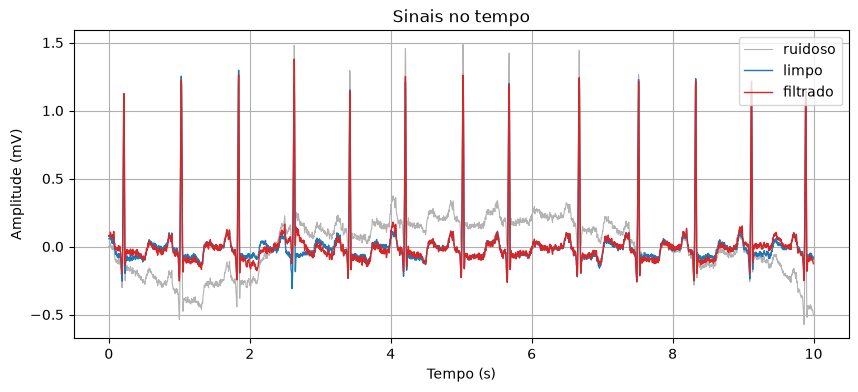

In [6]:
ref = apply_highpass(clean)
noisy = contaminate(clean, 'bw', 6); filt = apply_highpass(noisy)
noisy_ref = noisy - clean + ref
print(summary(ref, noisy_ref, filt))
plots.plot_time_overlay(clean=ref, noisy=noisy_ref, filtered=filt, fs=fs, n=3600)

## 3. Passa-baixa FIR Hamming 40 Hz (`firwin`, 61 taps)

FIR de fase linear → atraso de grupo constante `(M-1)/2 = 30` amostras. Avaliar em fase-zero (`filtfilt`) ou compensar o atraso.

atraso de grupo: 30.0 amostras


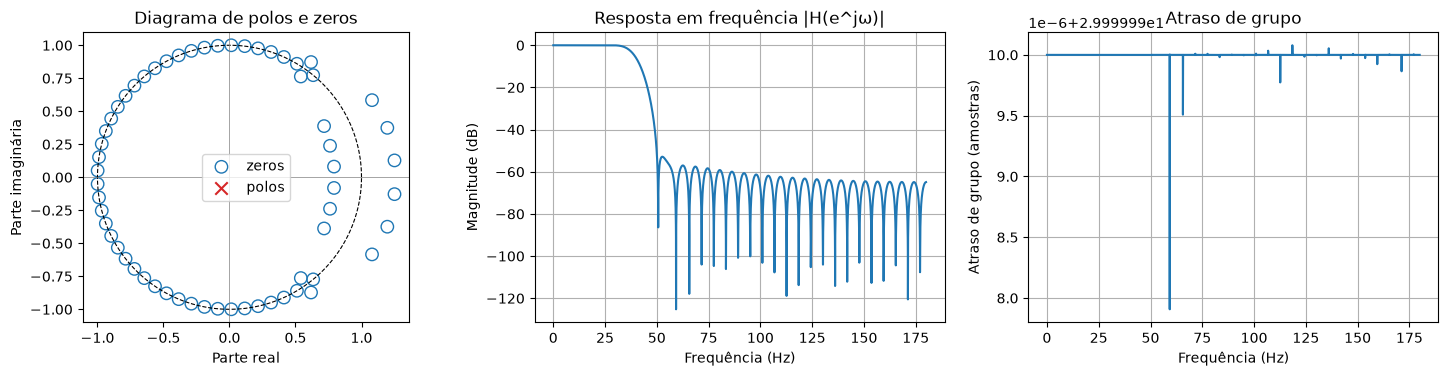

In [7]:
taps = design_lowpass_fir(fc=40, fs=fs, numtaps=61, window='hamming')
print('atraso de grupo:', group_delay_samples(61), 'amostras')
fig, axs = plt.subplots(1, 3, figsize=(15,4))
plots.plot_pole_zero(taps, [1.0], ax=axs[0])
plots.plot_freq_response(taps, fs=fs, ax=axs[1])
plots.plot_group_delay(taps, [1.0], fs=fs, ax=axs[2]); fig.tight_layout()

In [8]:
noisy = contaminate(clean, 'ma', 6)
filt = apply_lowpass_fir(noisy, zero_phase=True)
print(summary(clean, noisy, filt))
# Δ SNR ≈ 0 contra ruído muscular banda-larga: limitação que motiva os avançados.

{'snr_in_db': 6.0, 'snr_out_db': 6.033319167376411, 'snr_improvement_db': 0.03331916737641105, 'rmse': 0.18080486812062987, 'prd': 49.92683567027567, 'corr': 0.7228523384135498}


## 4. Tabela comparativa (protocolo correto)

In [9]:
import importlib.util, pathlib
spec = importlib.util.spec_from_file_location('gf', pathlib.Path.cwd().parent/'scripts'/'gerar_figuras.py')
gf = importlib.util.module_from_spec(spec); spec.loader.exec_module(gf)
gf.tabela_comparativa('100')

,filtro,ruido,snr_in_alvo,snr_out_db,delta_snr_db,prd_pct,corr
0,Notch 60Hz,60hz,0,34.57,34.57,1.87,0.999
1,Notch 60Hz,60hz,6,34.57,28.57,1.87,0.999
2,Notch 60Hz,60hz,12,34.57,22.57,1.87,0.999
3,Notch 60Hz,60hz,18,34.57,16.57,1.87,0.999
4,Passa-alta 0.5Hz,bw,0,12.85,18.64,22.77,0.975
5,Passa-alta 0.5Hz,bw,6,18.85,18.64,11.41,0.994
6,Passa-alta 0.5Hz,bw,12,24.85,18.64,5.72,0.998
7,Passa-alta 0.5Hz,bw,18,30.85,18.64,2.87,1.000
8,Passa-baixa FIR 40Hz,ma,0,0.08,0.09,99.08,0.467
9,Passa-baixa FIR 40Hz,ma,6,6.02,0.03,49.99,0.722
